
# Bipartite Kuramoto Clustering — `script.ipynb`

Pipeline por **bloques** para clustering con **Kuramoto bipartito**:
1) Matriz N×M (aleatoria o CSV local)  
2) Normalización [0,1]  
3) Multiplicar por 2π → fases Θ  
4) Promedios por fila/columna → fases iniciales  
5) Integración Kuramoto (RK4, ω=0, K uniforme)  
6) Afinidades (PLV): cruzada, intra-filas, intra-columnas  
7) Coherencia global y por partición, resumen y gráfico  

**Bloque extra:** clustering de **ELEMENTOS (i,j)** de `A_cross` para etiquetar coordenadas de la matriz original `X`.


In [21]:

# ==============================
# Configuración general
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Dimensiones (solo si USE_CSV=False)
N = 150
M = 100

# Rango enteros aleatorios (inclusivo)
RAND_MIN = 0
RAND_MAX = 100

# Semilla
SEED = 42

# Acoplamiento uniforme
K = 1.0

# Integración (RK4)
dt = 0.01
T_total = 5.0
NUM_STEPS = int(T_total / dt)

# Entrada por CSV (misma carpeta del notebook)
USE_CSV = False     # Cambiar a True para cargar CSV
CSV_NAME = None     # Si None, se detecta el primer .csv
CSV_DELIMITER = ","

# Guardado
SAVE_PREFIX = "kuramoto_bipartito"
SAVE_CSV = True
SAVE_PNG = True

np.random.seed(SEED)
print(f"Config -> N={N}, M={M}, RAND=[{RAND_MIN},{RAND_MAX}], K={K}, dt={dt}, T={T_total}s")


Config -> N=150, M=100, RAND=[0,100], K=1.0, dt=0.01, T=5.0s


In [2]:
# ==============================
# Cargar archivo CSV / OTUS desde ruta
# ==============================
import pandas as pd
import numpy as np
from pathlib import Path

# Ruta del archivo (TÚ LA DEFINES AQUÍ)
# Ejemplos válidos:
# FILE_PATH = r"D:\datos\otu_data.otus"
# FILE_PATH = "./data/tabla.csv"
# FILE_PATH = "/home/user/matrices/matriz.otus"

FILE_PATH = r"C:\Users\josep\Documents\Proyectos\Proyectos_Python\Clustering_Microbiota\Datos\otu_data.otus"   # <<< MODIFÍCALA AQUÍ


def load_matrix_from_path(path):
    """
    Carga una matriz numérica desde un archivo .csv o .otus.
    La ruta debe ser absoluta o relativa.
    """
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"No existe el archivo: {path}")

    ext = path.suffix.lower()

    if ext == ".csv":
        df = pd.read_csv(path, delimiter=",")
    elif ext == ".otus":
        df = pd.read_csv(path, sep="\t")  # Formato típico OTU
    else:
        raise ValueError(f"Formato no soportado: {ext}. Usa .csv o .otus")

    # Mantener únicamente columnas numéricas
    df_numeric = df.select_dtypes(include=[np.number])

    if df_numeric.empty:
        raise ValueError(f"El archivo {path.name} no contiene columnas numéricas.")

    return df_numeric.values.astype(float)


# ==============================
# Carga de la matriz
# ==============================
X = load_matrix_from_path(FILE_PATH)
print(f"✅ Archivo cargado: {FILE_PATH} → matriz {X.shape}")


✅ Archivo cargado: C:\Users\josep\Documents\Proyectos\Proyectos_Python\Clustering_Microbiota\Datos\otu_data.otus → matriz (441, 4738)


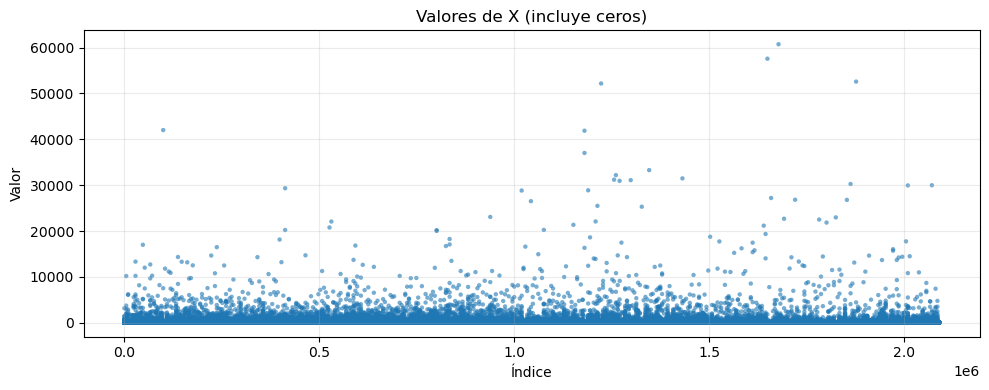

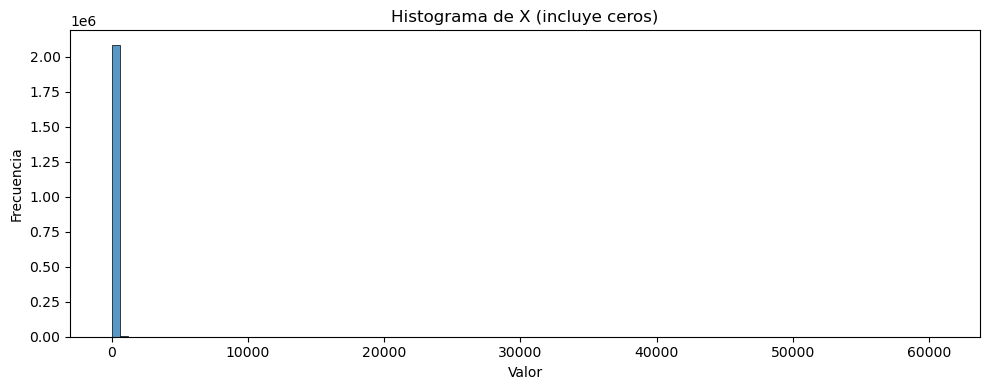

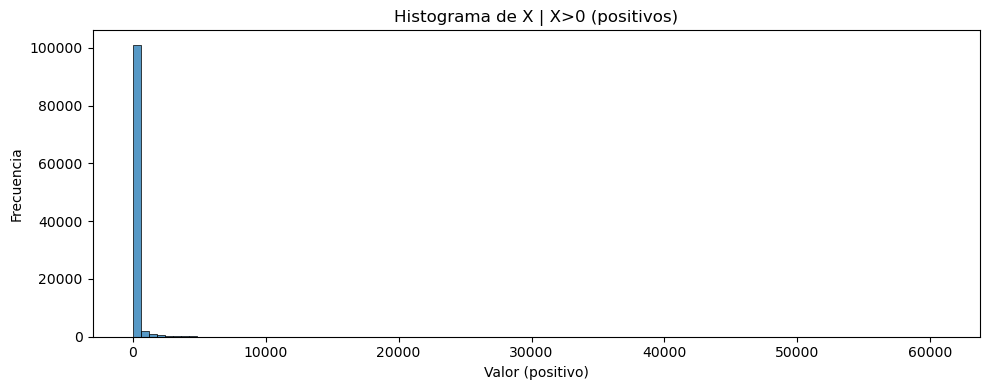

In [3]:
# =========================================
# EXTRACTO: Gráfico de dispersión + Histogramas
#   (incluye ceros y opcionalmente solo positivos)
# =========================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Preparar datos (mismo criterio que tu bloque)
X_arr = np.asarray(X, dtype=float)
valores = X_arr.flatten()
n = len(valores)

valores_pos = valores[valores > 0]
npos = len(valores_pos)

# -----------------------------
# A) Gráfico de dispersión (incluye ceros)
# -----------------------------
plt.figure(figsize=(10, 4))
plt.scatter(np.arange(n), valores, s=10, alpha=0.6, edgecolor="none")
plt.title("Valores de X (incluye ceros)")
plt.xlabel("Índice")
plt.ylabel("Valor")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# -----------------------------
# B) Histograma (incluye ceros)
# -----------------------------
plt.figure(figsize=(10, 4))
sns.histplot(valores, bins=100, kde=False)
plt.title("Histograma de X (incluye ceros)")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# -----------------------------
# C) Histograma (solo positivos)
# -----------------------------
if npos > 0:
    plt.figure(figsize=(10, 4))
    sns.histplot(valores_pos, bins=100, kde=False)
    plt.title("Histograma de X | X>0 (positivos)")
    plt.xlabel("Valor (positivo)")
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()
else:
    print("⚠ No hay valores positivos para graficar el histograma de X|X>0.")


In [5]:
# =========================================
# EXTRACTO: Reporte de información general (SIN gráficas)
#   -> N total, ceros, positivos, min/max
#   -> Columnas totalmente cero (si X es 2D)
# =========================================

import numpy as np

# -----------------------------
# 1. Preparar datos
# -----------------------------
X_arr = np.asarray(X, dtype=float)
valores = X_arr.flatten()
n = len(valores)

n0 = int(np.sum(valores == 0))
npos = int(np.sum(valores > 0))
pi_hat = n0 / n

# ---- Columnas totalmente cero ----
if X_arr.ndim == 2:
    cols_all_zero_mask = np.all(X_arr == 0, axis=0)
    n_cols_all_zero = int(np.sum(cols_all_zero_mask))
    n_cols = int(X_arr.shape[1])
    cols_all_zero_idx = np.where(cols_all_zero_mask)[0]
else:
    n_cols_all_zero = None
    n_cols = None
    cols_all_zero_idx = None

print(f"N total: {n}")
print(f"Ceros:   {n0}  ({100*pi_hat:.2f}%)")
print(f"Positivos: {npos}  ({100*(1-pi_hat):.2f}%)")
print(f"Min: {valores.min():.4g}, Max: {valores.max():.4g}")

if X_arr.ndim == 2:
    print(f"Columnas totales: {n_cols}")
    print(f"Columnas totalmente cero: {n_cols_all_zero} ({100*n_cols_all_zero/max(n_cols,1):.2f}%)")
    if n_cols_all_zero > 0:
        print(f"Índices de columnas todo-cero (0-based): {cols_all_zero_idx.tolist()}")

valores_pos = valores[valores > 0]


N total: 2089458
Ceros:   1984038  (94.95%)
Positivos: 105420  (5.05%)
Min: 0, Max: 6.071e+04
Columnas totales: 4738
Columnas totalmente cero: 18 (0.38%)
Índices de columnas todo-cero (0-based): [1862, 2422, 3116, 3174, 3182, 3249, 3342, 3432, 3497, 3540, 3673, 3746, 3798, 4186, 4283, 4578, 4646, 4655]


In [6]:
# =========================================
# EXTRACTO: Anderson–Darling (SIN MUESTREO) para:
#   - norm, logistic, gumbel_l, gumbel_r  (sobre TODOS los datos: incluye ceros)
#   - norm, expon, logistic, gumbel_l, gumbel_r (sobre X>0)
#   - lognormal (vía anderson sobre log(X>0) vs Normal)
#   -> Mantiene formato de impresión/mensajes
# =========================================

import numpy as np
from scipy.stats import anderson

# -----------------------------
# 0. Parámetros
# -----------------------------
ALPHA = 0.05   # <-- cambia aquí (ej: 0.01, 0.10, etc.)

# -----------------------------
# 1. Preparar datos
# -----------------------------
X_arr = np.asarray(X, dtype=float)
valores = X_arr.flatten()
valores = valores[np.isfinite(valores)]

n_all = int(len(valores))
n0 = int(np.sum(valores == 0))
npos = int(np.sum(valores > 0))

valores_pos = valores[valores > 0]

# -----------------------------
# Utilidad interna para imprimir igual
# -----------------------------
def _print_anderson_block(data, dist_code, header, ALPHA):
    ad = anderson(data, dist=dist_code)
    print(f"\n{header}")
    print(f"  AD stat = {ad.statistic:.4f}")

    alpha_pct = 100 * ALPHA
    levels = np.asarray(ad.significance_level, dtype=float)  # ej: [15, 10, 5, 2.5, 1]
    crits  = np.asarray(ad.critical_values, dtype=float)

    idx_near = int(np.argmin(np.abs(levels - alpha_pct)))
    level_used = float(levels[idx_near])
    crit_used  = float(crits[idx_near])

    for sl, cv in zip(levels, crits):
        print(f"  crit @ {sl:4.1f}%: {cv:.4f}")

    if ad.statistic > crit_used:
        print(f"  Decisión (≈α={ALPHA}, usando crítico {level_used}%): SE rechaza (AD > crit).")
    else:
        print(f"  Decisión (≈α={ALPHA}, usando crítico {level_used}%): NO se rechaza (AD ≤ crit).")

# -----------------------------
# 2) Anderson-Darling en TODOS los datos (incluye ceros) donde aplica
# -----------------------------
# OJO: expon y lognormal NO tienen sentido con masa puntual en 0 (lognormal exige X>0)
dists_all = [
    ("norm",     "Normalidad de X (incluye ceros) (Anderson-Darling, muestra):"),
    ("logistic", "Logística de X (incluye ceros) (Anderson-Darling, muestra):"),
    ("gumbel_l", "Gumbel (izq) de X (incluye ceros) (Anderson-Darling, muestra):"),
    ("gumbel_r", "Gumbel (der) de X (incluye ceros) (Anderson-Darling, muestra):"),
]

if n_all == 0:
    print("⚠ No hay datos finitos en X.")
else:
    for dist_code, header in dists_all:
        _print_anderson_block(valores, dist_code, header, ALPHA)

# -----------------------------
# 3) Anderson-Darling en positivos (X>0)
# -----------------------------
if npos == 0:
    print("⚠ No hay valores positivos. No tiene sentido ajustar lognormal/gamma/expon.")
else:
    dists_pos = [
        ("norm",     "Normalidad de X>0 (Anderson-Darling, muestra):"),
        ("expon",    "Exponencialidad de X>0 (Anderson-Darling, muestra):"),
        ("logistic", "Logística de X>0 (Anderson-Darling, muestra):"),
        ("gumbel_l", "Gumbel (izq) de X>0 (Anderson-Darling, muestra):"),
        ("gumbel_r", "Gumbel (der) de X>0 (Anderson-Darling, muestra):"),
    ]

    for dist_code, header in dists_pos:
        _print_anderson_block(valores_pos, dist_code, header, ALPHA)

    # -----------------------------
    # 4) Lognormalidad (X lognormal <=> log(X) normal)
    # -----------------------------
    log_vals = np.log(valores_pos)
    log_vals = log_vals[np.isfinite(log_vals)]  # por seguridad numérica

    ad_ln = anderson(log_vals, dist="norm")
    print("\nLognormalidad de X (Anderson-Darling sobre log(X>0) vs Normal, muestra):")
    print(f"  AD stat = {ad_ln.statistic:.4f}")

    alpha_pct = 100 * ALPHA
    levels = np.asarray(ad_ln.significance_level, dtype=float)
    crits  = np.asarray(ad_ln.critical_values, dtype=float)

    idx_near = int(np.argmin(np.abs(levels - alpha_pct)))
    level_used = float(levels[idx_near])
    crit_used  = float(crits[idx_near])

    for sl, cv in zip(levels, crits):
        print(f"  crit @ {sl:4.1f}%: {cv:.4f}")

    if ad_ln.statistic > crit_used:
        print(f"  Decisión (≈α={ALPHA}, usando crítico {level_used}%): SE rechaza lognormalidad (AD > crit).")
    else:
        print(f"  Decisión (≈α={ALPHA}, usando crítico {level_used}%): NO se rechaza lognormalidad (AD ≤ crit).")



Normalidad de X (incluye ceros) (Anderson-Darling, muestra):
  AD stat = 781495.7745
  crit @ 15.0%: 0.5760
  crit @ 10.0%: 0.6560
  crit @  5.0%: 0.7870
  crit @  2.5%: 0.9180
  crit @  1.0%: 1.0920
  Decisión (≈α=0.05, usando crítico 5.0%): SE rechaza (AD > crit).


C:\Users\josep\anaconda3\Lib\site-packages\scipy\stats\_morestats.py:2232: RuntimeWarning: overflow encountered in exp
  tmp2 = exp(tmp)
C:\Users\josep\anaconda3\Lib\site-packages\scipy\stats\_morestats.py:2234: RuntimeWarning: overflow encountered in multiply
  np.sum(tmp*(1.0-tmp2)/(1+tmp2), axis=0) + N]
C:\Users\josep\anaconda3\Lib\site-packages\scipy\stats\_morestats.py:2234: RuntimeWarning: invalid value encountered in divide
  np.sum(tmp*(1.0-tmp2)/(1+tmp2), axis=0) + N]



Logística de X (incluye ceros) (Anderson-Darling, muestra):
  AD stat = 4941916.7600
  crit @ 25.0%: 0.4260
  crit @ 10.0%: 0.5630
  crit @  5.0%: 0.6600
  crit @  2.5%: 0.7690
  crit @  1.0%: 0.9060
  crit @  0.5%: 1.0100
  Decisión (≈α=0.05, usando crítico 5.0%): SE rechaza (AD > crit).

Gumbel (izq) de X (incluye ceros) (Anderson-Darling, muestra):
  AD stat = 882488.0804
  crit @ 25.0%: 0.4740
  crit @ 10.0%: 0.6370
  crit @  5.0%: 0.7570
  crit @  2.5%: 0.8770
  crit @  1.0%: 1.0380
  Decisión (≈α=0.05, usando crítico 5.0%): SE rechaza (AD > crit).

Gumbel (der) de X (incluye ceros) (Anderson-Darling, muestra):
  AD stat = inf
  crit @ 25.0%: 0.4740
  crit @ 10.0%: 0.6370
  crit @  5.0%: 0.7570
  crit @  2.5%: 0.8770
  crit @  1.0%: 1.0380
  Decisión (≈α=0.05, usando crítico 5.0%): SE rechaza (AD > crit).

Normalidad de X>0 (Anderson-Darling, muestra):
  AD stat = 31514.2886
  crit @ 15.0%: 0.5760
  crit @ 10.0%: 0.6560
  crit @  5.0%: 0.7870
  crit @  2.5%: 0.9180
  crit @  1.0%

In [7]:
# =========================================
# EXTRACTO: Comparación por BIC (SOLO positivos + HURDLE total) - SIN MUESTREO
# =========================================

import numpy as np
import pandas as pd
from scipy.stats import lognorm, gamma, expon
from statsmodels.tools.eval_measures import bic as sm_bic

# 1) Preparar datos
X_arr = np.asarray(X, dtype=float)
valores = X_arr.flatten()
n = len(valores)

n0 = int(np.sum(valores == 0))
npos = int(np.sum(valores > 0))
pi_hat = n0 / n if n > 0 else np.nan

valores_pos = valores[valores > 0]

if npos == 0:
    print("⚠ No hay valores positivos. No tiene sentido ajustar lognormal/gamma/expon.")
else:
    # SIN MUESTREO: usamos TODOS los positivos
    data_fit = valores_pos

    # ----- Ajustes (solo positivos) -----
    # Lognormal (floc=0)
    sigma_ln, loc_ln, scale_ln = lognorm.fit(data_fit, floc=0)
    ll_ln = float(np.sum(lognorm.logpdf(data_fit, sigma_ln, loc=loc_ln, scale=scale_ln)))
    mu_ln = float(np.log(scale_ln))
    params_ln = (mu_ln, float(sigma_ln), float(loc_ln), float(scale_ln))

    # Gamma (floc=0)
    a_g, loc_g, scale_g = gamma.fit(data_fit, floc=0)
    ll_g = float(np.sum(gamma.logpdf(data_fit, a_g, loc=loc_g, scale=scale_g)))
    params_g = (float(a_g), float(loc_g), float(scale_g))

    # Expon (floc=0)
    loc_e, scale_e = expon.fit(data_fit, floc=0)
    ll_e = float(np.sum(expon.logpdf(data_fit, loc=loc_e, scale=scale_e)))
    params_e = (float(loc_e), float(scale_e))

    # Info criteria para SOLO positivos (SOLO BIC)
    rows_pos = [
        {"modelo_pos": "pos_lognormal", "BIC_pos": sm_bic(ll_ln, len(data_fit), 2)},
        {"modelo_pos": "pos_gamma",     "BIC_pos": sm_bic(ll_g,  len(data_fit), 2)},
        {"modelo_pos": "pos_expon",     "BIC_pos": sm_bic(ll_e,  len(data_fit), 1)},
    ]

    df_pos = pd.DataFrame(rows_pos).sort_values("BIC_pos")
    print("\nComparación SOLO positivos (componente continuo):")
    try:
        display(df_pos)  # Jupyter
    except NameError:
        print(df_pos.to_string(index=False))

    best_pos = df_pos.iloc[0]["modelo_pos"]
    print(f"➜ Mejor en positivos por BIC: {best_pos}")

    # ----- Modelos TOTAL (HURDLE) (SOLO BIC) -----
    pi_clip = float(np.clip(pi_hat, 1e-12, 1 - 1e-12))
    ll_hurdle_base = float(n0 * np.log(pi_clip) + len(data_fit) * np.log(1.0 - pi_clip))

    total_rows = [
        {
            "modelo_total": "hurdle_lognormal",
            "BIC_total": sm_bic(ll_hurdle_base + ll_ln, n0 + len(data_fit), 3),  # k = 1(pi) + 2(positivo)
            "pi_hat": pi_hat,
            "params": params_ln
        },
        {
            "modelo_total": "hurdle_gamma",
            "BIC_total": sm_bic(ll_hurdle_base + ll_g, n0 + len(data_fit), 3),   # k = 1(pi) + 2(positivo)
            "pi_hat": pi_hat,
            "params": params_g
        },
        {
            "modelo_total": "hurdle_expon",
            "BIC_total": sm_bic(ll_hurdle_base + ll_e, n0 + len(data_fit), 2),   # k = 1(pi) + 1(positivo)
            "pi_hat": pi_hat,
            "params": params_e
        },
    ]

    df_total = pd.DataFrame(total_rows).sort_values("BIC_total")
    print("\nComparación TOTAL (hurdle: incluye masa en cero + positivos):")
    try:
        display(df_total)  # Jupyter
    except NameError:
        print(df_total.to_string(index=False))

    best_total = df_total.iloc[0]["modelo_total"]
    print(f"➜ Mejor modelo TOTAL por BIC: {best_total}")



Comparación SOLO positivos (componente continuo):


,modelo_pos,BIC_pos
0,pos_lognormal,9.510464e+05
1,pos_gamma,1.039826e+06
2,pos_expon,1.252628e+06


➜ Mejor en positivos por BIC: pos_lognormal

Comparación TOTAL (hurdle: incluye masa en cero + positivos):


,modelo_total,BIC_total,pi_hat,params
0,hurdle_lognormal,1.786214e+06,0.949547,"(2.421416919873371, 1.9547925104016337, 0.0, 1..."
1,hurdle_gamma,1.874993e+06,0.949547,"(0.27721857931517724, 0.0, 504.73086757865093)"
2,hurdle_expon,2.087793e+06,0.949547,"(0.0, 139.92077404667046)"


➜ Mejor modelo TOTAL por BIC: hurdle_lognormal


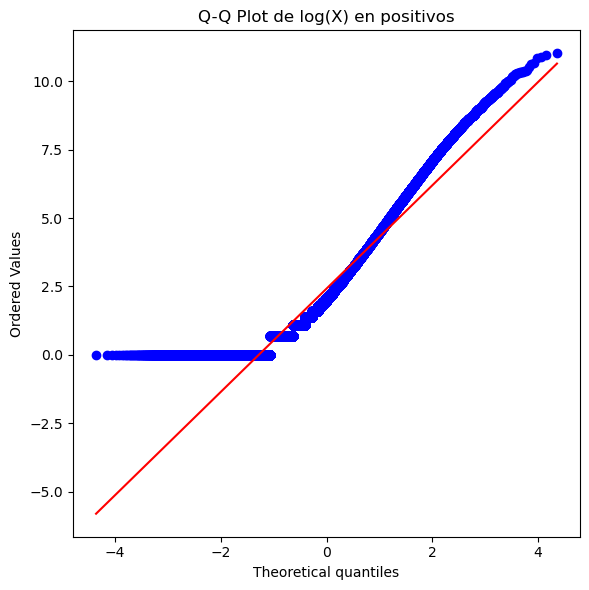

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import probplot

# --- Datos (mismo criterio que tu bloque) ---
X_arr = np.asarray(X, dtype=float)
valores = X_arr.flatten()
valores_pos = valores[valores > 0]
npos = len(valores_pos)

if npos == 0:
    raise ValueError("No hay valores positivos para hacer Q-Q plot de log(X).")

# --- Muestra (igual que tu bloque) ---
rng = np.random.default_rng(42)
sample_size = min(npos, 5000)
muestra = rng.choice(valores_pos, size=sample_size, replace=False)

# --- Transformación para lognormalidad ---
log_vals = np.log(valores_pos)

# --- Q-Q plot usando librería (scipy) ---
fig = plt.figure(figsize=(6, 6))
probplot(log_vals, dist="norm", plot=plt)
plt.title("Q-Q Plot de log(X) en positivos")
plt.tight_layout()
plt.show()


KDE sobre todos los datos
N = 2089458, min=0, max=6.071e+04


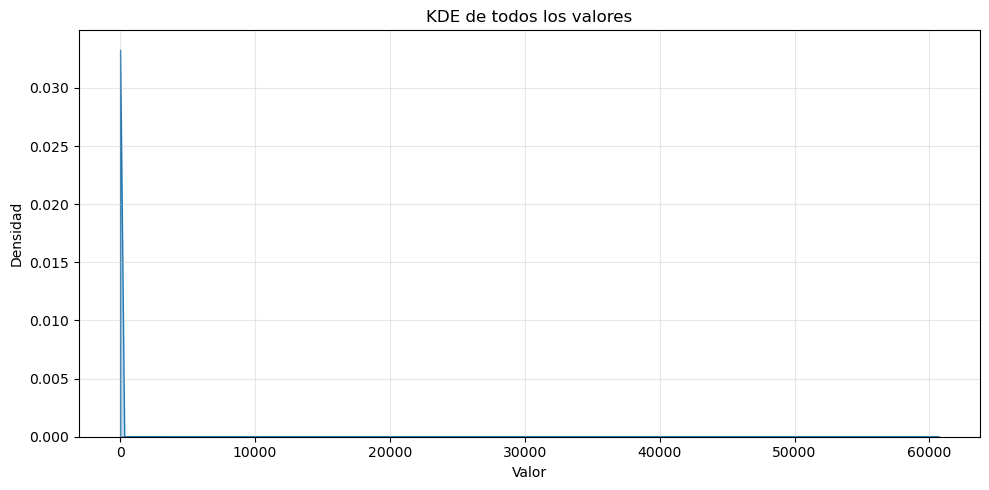

In [10]:
# =========================================
# KDE (Kernel Density Estimation) sobre X
#   -> todo el conjunto o solo positivos
# =========================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 0) Preparar datos
valores = X.flatten().astype(float)
valores = valores[np.isfinite(valores)]
valores_pos = valores[valores > 0]

# 1) Selector: todo vs positivos
usar_solo_positivos = False   # <-- cambia a False para usar todo el conjunto
data_kde = valores_pos if usar_solo_positivos else valores

if len(data_kde) == 0:
    raise ValueError("No hay datos para KDE con la selección actual.")

print(f"KDE sobre {'positivos' if usar_solo_positivos else 'todos'} los datos")
print(f"N = {len(data_kde)}, min={data_kde.min():.4g}, max={data_kde.max():.4g}")

# 2) KDE con seaborn (incluye control de bandwidth)
plt.figure(figsize=(10, 5))
sns.kdeplot(
    data_kde,
    fill=True,
    bw_method="silverman",   # "scott" o "silverman" o un número (ej. 0.3) para afinar
    cut=0                # evita extender demasiado fuera del rango
)
plt.title(f"KDE de {'valores > 0' if usar_solo_positivos else 'todos los valores'}")
plt.xlabel("Valor")
plt.ylabel("Densidad")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


KDE sobre positivos los datos
N = 105420, min=1, max=6.071e+04


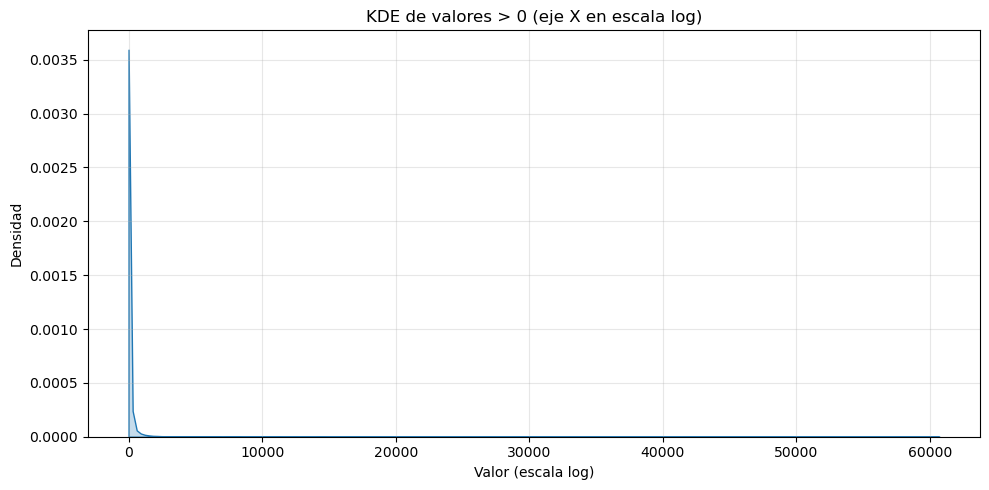

In [12]:
# =========================================
# KDE (Kernel Density Estimation) sobre X (ESCALA LOG)
#   -> en escala logarítmica solo es válido si se grafican POSITIVOS
# =========================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 0) Preparar datos
valores = X.flatten().astype(float)
valores = valores[np.isfinite(valores)]
valores_pos = valores[valores > 0]

# 1) Selector: todo vs positivos
usar_solo_positivos = True   # ⚠ requerido para escala log en el eje X
data_kde = valores_pos if usar_solo_positivos else valores

if len(data_kde) == 0:
    raise ValueError("No hay datos para KDE con la selección actual.")

print(f"KDE sobre {'positivos' if usar_solo_positivos else 'todos'} los datos")
print(f"N = {len(data_kde)}, min={data_kde.min():.4g}, max={data_kde.max():.4g}")

# 2) KDE con seaborn
plt.figure(figsize=(10, 5))
sns.kdeplot(
    data_kde,
    fill=True,
    bw_method="silverman",
    cut=0
)

#plt.xscale("log")  # <-- escala logarítmica en X (solo positivos)
plt.title("KDE de valores > 0 (eje X en escala log)")
plt.xlabel("Valor (escala log)")
plt.ylabel("Densidad")
plt.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.show()


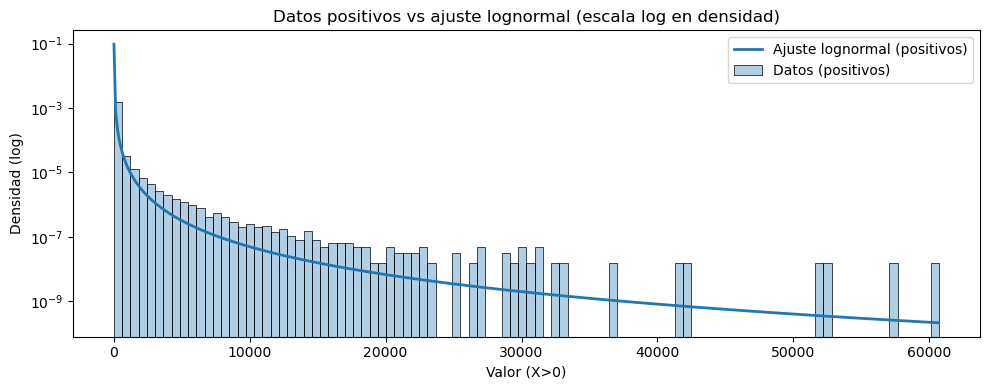

In [13]:
# =========================================
# EXTRACTO: Datos positivos vs ajuste LOGNORMAL
#   (histograma en densidad + curva PDF lognormal ajustada)
# =========================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import lognorm

# 1) Preparar datos (mismo criterio del bloque)
X_arr = np.asarray(X, dtype=float)
valores = X_arr.flatten()
valores_pos = valores[valores > 0]

if len(valores_pos) == 0:
    raise ValueError("⚠ No hay valores positivos para ajustar lognormal.")

# (Opcional) limitar puntos para que el ajuste sea manejable en datasets enormes
#MAX_FIT = 20000
#rng = np.random.default_rng(123)
#data_fit = valores_pos if len(valores_pos) <= MAX_FIT else rng.choice(valores_pos, size=MAX_FIT, replace=False)
data_fit=valores_pos

# 2) Ajuste lognormal (soporte positivo)
sigma, loc, scale = lognorm.fit(data_fit, floc=0)

# 3) Curva ajustada vs histograma (solo positivos)
xgrid = np.linspace(valores_pos.min(), valores_pos.max(), 500)

plt.figure(figsize=(10, 4))
sns.histplot(valores_pos, bins=100, stat="density", alpha=0.35, label="Datos (positivos)")
pdf = lognorm.pdf(xgrid, sigma, loc=loc, scale=scale)
plt.plot(xgrid, pdf, linewidth=2, label="Ajuste lognormal (positivos)")

plt.yscale("log")  # escala log en densidad (como tu bloque)
plt.title("Datos positivos vs ajuste lognormal (escala log en densidad)")
plt.xlabel("Valor (X>0)")
plt.ylabel("Densidad (log)")
plt.legend()
plt.tight_layout()
plt.show()


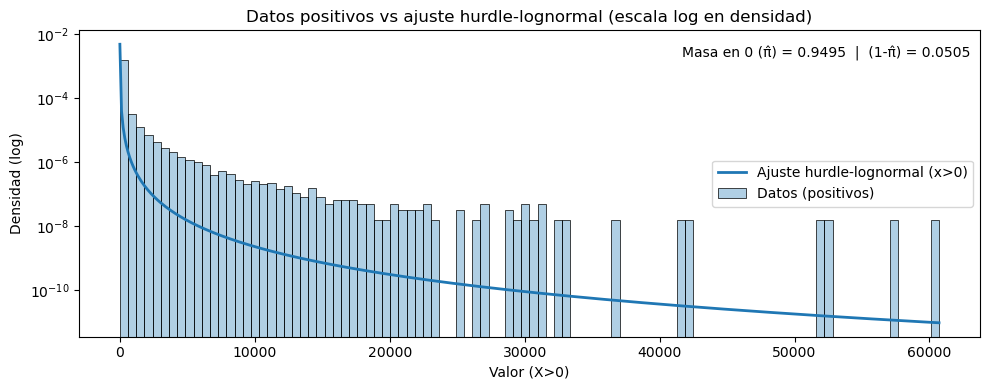

In [14]:
# =========================================
# EXTRACTO: Datos positivos vs ajuste HURDLE-LOGNORMAL
#   - Histograma densidad de X>0
#   - Curva del modelo hurdle en x>0: (1 - pi_hat) * pdf_lognormal(x)
#   - Reporta la masa en cero pi_hat (anotación)
# =========================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import lognorm

# 1) Preparar datos
X_arr = np.asarray(X, dtype=float)
valores = X_arr.flatten()
valores_pos = valores[valores > 0]

n = len(valores)
n0 = int(np.sum(valores == 0))
pi_hat = n0 / n if n > 0 else np.nan  # masa estimada en 0

if len(valores_pos) == 0:
    raise ValueError("⚠ No hay valores positivos para ajustar hurdle-lognormal.")

# (Opcional) limitar puntos para que el ajuste sea manejable en datasets enormes
MAX_FIT = 20000
rng = np.random.default_rng(123)
data_fit = valores_pos if len(valores_pos) <= MAX_FIT else rng.choice(valores_pos, size=MAX_FIT, replace=False)

# 2) Ajuste lognormal del componente positivo (soporte positivo)
sigma, loc, scale = lognorm.fit(data_fit, floc=0)

# 3) Curva hurdle vs histograma (solo positivos)
xgrid = np.linspace(valores_pos.min(), valores_pos.max(), 500)

plt.figure(figsize=(10, 4))
sns.histplot(valores_pos, bins=100, stat="density", alpha=0.35, label="Datos (positivos)")

pdf_pos = lognorm.pdf(xgrid, sigma, loc=loc, scale=scale)          # pdf condicional del componente positivo
pdf_hurdle = (1.0 - pi_hat) * pdf_pos                              # densidad *no-condicional* para x>0

plt.plot(xgrid, pdf_hurdle, linewidth=2, label="Ajuste hurdle-lognormal (x>0)")

plt.yscale("log")  # escala log en densidad
plt.title("Datos positivos vs ajuste hurdle-lognormal (escala log en densidad)")
plt.xlabel("Valor (X>0)")
plt.ylabel("Densidad (log)")
plt.legend()

# Anotación de la masa en cero (no es densidad continua)
plt.text(
    0.99, 0.95,
    f"Masa en 0 (π̂) = {pi_hat:.4f}  |  (1-π̂) = {1.0-pi_hat:.4f}",
    ha="right", va="top",
    transform=plt.gca().transAxes
)

plt.tight_layout()
plt.show()


In [15]:

# ==============================
# Bloque 2: Normalización [0,1]
# ==============================
X_min = float(np.min(X))
X_max = float(np.max(X))
if X_max == X_min:
    X_norm = np.ones_like(X)
else:
    X_norm = (X - X_min) / (X_max - X_min)

print(f"Normalización: min={X_min:.6g}, max={X_max:.6g}")
print(f"Rango X_norm -> [{X_norm.min():.6f}, {X_norm.max():.6f}]")


Normalización: min=0, max=60711
Rango X_norm -> [0.000000, 1.000000]


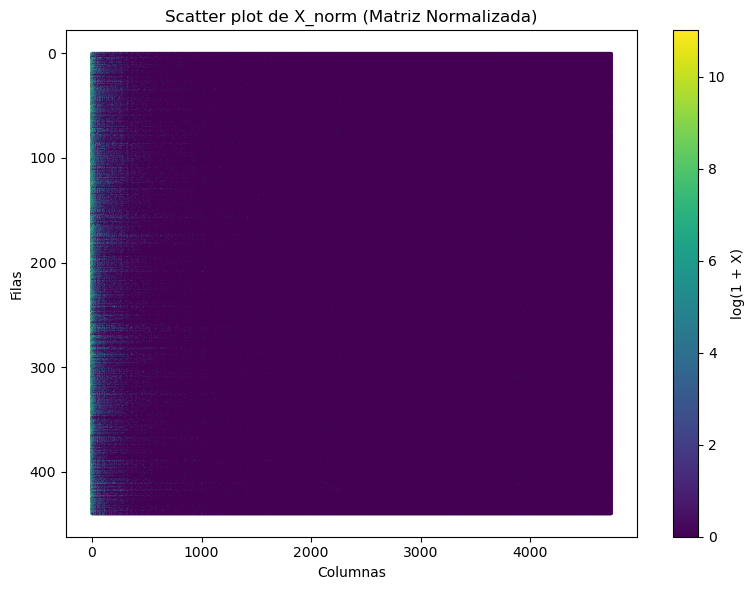

In [16]:
# ==============================
# Bloque 3: Gráfico de puntos (scatter) de X_norm
# ==============================
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))

# Si es vector 1D → puntos simples
if X_norm.ndim == 1:
    plt.scatter(np.arange(len(X_norm)), X_norm, s=25)
    plt.title("Scatter plot de X_norm (Vector Normalizado)")
    plt.xlabel("Índice")
    plt.ylabel("Valor Normalizado [0,1]")

# Si es matriz 2D → puntos por posición
elif X_norm.ndim == 2:
    filas, cols = X_norm.shape

    # Generar coordenadas de cada punto
    xs, ys = np.meshgrid(np.arange(cols), np.arange(filas))

    plt.scatter(xs.flatten(), ys.flatten(),
            c=np.log1p(X), cmap="viridis", s=1)

    plt.title("Scatter plot de X_norm (Matriz Normalizada)")
    plt.xlabel("Columnas")
    plt.ylabel("Filas")
    plt.gca().invert_yaxis()  # solo visual, opcional

else:
    raise ValueError("X_norm debe ser 1D o 2D.")

plt.colorbar(label="log(1 + X)")
plt.tight_layout()
plt.show()


In [17]:

# ==============================
# Bloque 3: Multiplicar por π
# ==============================
TWO_PI = np.pi
Theta = TWO_PI * X_norm   # fases base (N x M)
print("Theta lista. Ejemplo [0,0]:", float(Theta[0,0]))


Theta lista. Ejemplo [0,0]: 0.018318324510727655


In [18]:
# ==============================
# Bloque 4: Media circular por fila y columna (promedio natural en S^1)
#   -> usando scipy.stats.circmean
# ==============================
import numpy as np
from scipy.stats import circmean

# Media circular por fila (N,) y por columna (M,)
# low=0, high=2π  -> salida en [0, 2π)
phi0 = circmean(Theta, high=TWO_PI, low=0.0, axis=1)
psi0 = circmean(Theta, high=TWO_PI, low=0.0, axis=0)

print("Fases iniciales (media circular S^1):")
print("phi0 (N) ->", phi0.shape, "  rango:[", float(phi0.min()), ",", float(phi0.max()), "]")
print("psi0 (M) ->", psi0.shape, "  rango:[", float(psi0.min()), ",", float(psi0.max()), "]")


Fases iniciales (media circular S^1):
phi0 (N) -> (441,)   rango:[ 1.510558172615441e-05 , 0.0010480622848369294 ]
psi0 (M) -> (4738,)   rango:[ 0.0 , 0.09930335360671412 ]


In [19]:
# ==============================
# Bloque 5: Kuramoto bipartito (integración con SciPy solve_ivp)
# ==============================
# dφ_i/dt = (K / M) * Σ_j W_ij * sin(ψ_j - φ_i)
# dψ_j/dt = (K / N) * Σ_i W_ij * sin(φ_i - ψ_j)
# ω = 0, W = X_norm (pre-2π)

import numpy as np
from scipy.integrate import solve_ivp

# W = X_norm[np.ix_(rows_keep, cols_keep)].copy()
W = X_norm.copy()

Nr = phi0.size
Mc = psi0.size

def kuramoto_rhs_flat(t, y, W, K, Nr, Mc):
    """
    RHS para solve_ivp con estado concatenado y = [phi (Nr), psi (Mc)].
    Nota: es inevitable tener una función RHS para cualquier integrador.
    """
    phi = y[:Nr]
    psi = y[Nr:Nr+Mc]

    phi_col = phi[:, None]   # Nr x 1
    psi_row = psi[None, :]   # 1 x Mc

    dphi = (K / max(1, Mc)) * np.sum(W * np.sin(psi_row - phi_col), axis=1)
    dpsi = (K / max(1, Nr)) * np.sum(W * np.sin(phi_col - psi_row), axis=0)

    return np.concatenate([dphi, dpsi])


# Estado inicial concatenado
y0 = np.concatenate([phi0.copy(), psi0.copy()])

# Malla temporal: NUM_STEPS puntos (como tu loop)
t_eval = np.linspace(0.0, T_total, NUM_STEPS)

# Integración (RK45 es el estándar; también puedes usar "DOP853" para más precisión)
sol = solve_ivp(
    fun=kuramoto_rhs_flat,
    t_span=(0.0, T_total),
    y0=y0,
    t_eval=t_eval,
    method="RK45",
    args=(W, K, Nr, Mc),
    vectorized=False
)

if not sol.success:
    raise RuntimeError(f"solve_ivp falló: {sol.message}")

# Reconstruir trayectorias
Y = sol.y.T  # (NUM_STEPS, Nr+Mc)
traj_phi = np.mod(Y[:, :Nr], TWO_PI)
traj_psi = np.mod(Y[:, Nr:Nr+Mc], TWO_PI)

print(f"Integración completada: pasos={NUM_STEPS}, dt≈{(T_total/(NUM_STEPS-1)):.6g}, T={T_total}s")


Integración completada: pasos=500, dt≈0.01002, T=5.0s


In [20]:

# ==============================
# Bloque 6: Matrices de afinidad (PLV)
# ==============================
def plv_matrices(traj_phi, traj_psi):
    Z_rows = np.exp(1j * traj_phi)  # T x N
    Z_cols = np.exp(1j * traj_psi)  # T x M
    Tsteps = traj_phi.shape[0]

    A_cross = np.abs((Z_rows.conj().T @ Z_cols) / Tsteps)  # N x M
    A_rows  = np.abs((Z_rows.conj().T @ Z_rows) / Tsteps)  # N x N
    A_cols  = np.abs((Z_cols.conj().T @ Z_cols) / Tsteps)  # M x M
    return A_cross, A_rows, A_cols

A_cross, A_rows, A_cols = plv_matrices(traj_phi, traj_psi)

print("Afinidades listas:")
print("A_cross (N x M):", A_cross.shape, "  rango:[", float(A_cross.min()), ",", float(A_cross.max()), "]")
print("A_rows  (N x N):", A_rows.shape)
print("A_cols  (M x M):", A_cols.shape)

if SAVE_CSV:
    pd.DataFrame(A_cross).to_csv(f"{SAVE_PREFIX}_A_cross.csv", index=False)
    pd.DataFrame(A_rows).to_csv(f"{SAVE_PREFIX}_A_rows.csv", index=False)
    pd.DataFrame(A_cols).to_csv(f"{SAVE_PREFIX}_A_cols.csv", index=False)
    print("Guardado CSV de afinidades.")


Afinidades listas:
A_cross (N x M): (441, 4738)   rango:[ 0.9999846265196576 , 0.9999999999999719 ]
A_rows  (N x N): (441, 441)
A_cols  (M x M): (4738, 4738)
Guardado CSV de afinidades.


In [30]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

from pyclustering.nnet.sync import initial_type
from pyclustering.cluster.syncnet import syncnet

import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"   


# ---------------------------------------------------------
# Utilidades
# ---------------------------------------------------------
def suggest_radius_knn(data, k=10, quantile=0.75, metric="euclidean"):
    """
    Sugiere un radio usando distancias al k-ésimo vecino.
    - k: vecindad
    - quantile: p.ej. 0.75 toma un radio relativamente "conectado"
    """
    data = np.asarray(data, dtype=float)
    if data.shape[0] <= k:
        raise ValueError("k es demasiado grande para el número de puntos.")

    nn = NearestNeighbors(n_neighbors=k + 1, metric=metric)  # +1 por el punto mismo
    nn.fit(data)
    dists, _ = nn.kneighbors(data)
    kth = dists[:, k]  # distancia al k-ésimo vecino (excluyendo self)
    r = float(np.quantile(kth, quantile))
    return r


def clusters_to_labels(n_points, clusters, noise=None):
    """
    Convierte clusters (listas de índices) a un vector de labels.
    noise -> label = -1
    """
    labels = np.full(n_points, -1, dtype=int)
    for cid, members in enumerate(clusters):
        for idx in members:
            labels[idx] = cid
    if noise is not None:
        for idx in noise:
            labels[idx] = -1
    return labels


def plot_clusters_2d(coords_2d, labels, title):
    """
    Scatter 2D de los clusters (labels = -1 se muestra como ruido).
    """
    coords_2d = np.asarray(coords_2d)
    labels = np.asarray(labels)

    plt.figure(figsize=(8, 6))
    # ruido
    noise_mask = labels == -1
    if np.any(noise_mask):
        plt.scatter(coords_2d[noise_mask, 0], coords_2d[noise_mask, 1], s=12, alpha=0.5, label="noise")

    # clusters
    for cid in sorted(set(labels[labels >= 0])):
        m = labels == cid
        plt.scatter(coords_2d[m, 0], coords_2d[m, 1], s=14, alpha=0.8, label=f"c{cid}")

    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend(markerscale=1.5, bbox_to_anchor=(1.04, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------
# Core: correr SyncNet y visualizar (sobre filas o columnas)
# ---------------------------------------------------------
def run_syncnet_and_plot(data, *, k=10, q=0.75, coupling=1.0, steps=250, dt=0.05, ccore=False, title=""):
    """
    - data: (n_points, n_features)
    - radio sugerido por kNN
    - SyncNet clustering
    - PCA 2D para visualizar
    """
    data = np.asarray(data, dtype=float)
    data = data[np.all(np.isfinite(data), axis=1)]  # limpia filas no finitas

    n_points = data.shape[0]
    if n_points < 3:
        raise ValueError("Muy pocos puntos para clusterizar.")

    # (1) radio sugerido
    radius = suggest_radius_knn(data, k=k, quantile=q)
    print(f"Radio sugerido (k={k}, q={q}): {radius:.6g}")

    # (2) SyncNet
    net = syncnet(
    data.tolist(),
    radius=radius,
    initial_phases=initial_type.RANDOM_GAUSSIAN,  # o initial_type.EQUIPARTITION
    ccore=ccore
    )
    ORDER = 0.995
    net.process(ORDER, steps)  # ✅ 2º argumento = steps (solution), NO dt

    clusters = net.get_clusters()
    noise = net.get_noise()

    labels = clusters_to_labels(n_points, clusters, noise=noise)

    print(f"Clusters encontrados: {len(clusters)}")
    print(f"Ruido (noise): {0 if noise is None else len(noise)}")

    # (3) PCA 2D para plot
    coords_2d = PCA(n_components=2, random_state=0).fit_transform(data)

    plot_clusters_2d(coords_2d, labels, title=title)
    return {
        "radius": radius,
        "clusters": clusters,
        "noise": noise,
        "labels": labels,
        "coords_2d": coords_2d,
    }


# ---------------------------------------------------------
# USO con tus datos
# ---------------------------------------------------------
# X_norm: shape (450, 4700), en [0,1]
X_arr = np.asarray(X_norm, dtype=float)

# A) Clustering de FILAS: 450 puntos en R^4700
result_rows = run_syncnet_and_plot(
    X_arr,
    k=10, q=0.75,
    coupling=1.0,
    steps=250, dt=0.05,
    ccore=False,
    title="SyncNet clusters - FILAS (PCA 2D)"
)

# B) Clustering de COLUMNAS: 4700 puntos en R^450
# (transponer: cada columna se vuelve un punto)
result_cols = run_syncnet_and_plot(
    X_arr.T,
    k=10, q=0.75,
    coupling=1.0,
    steps=250, dt=0.05,
    ccore=False,
    title="SyncNet clusters - COLUMNAS (PCA 2D)"
)


Radio sugerido (k=10, q=0.75): 0.148542


NameError: Solver '250' is not supported

In [14]:
# ==============================
# Bloque 7: Prueba determinista matriz de afinidad
# ==============================

def run_once_get_Across(phi_init, psi_init):
    phi = phi_init.copy(); psi = psi_init.copy()
    traj_phi = np.empty((NUM_STEPS, phi.size), float)
    traj_psi = np.empty((NUM_STEPS, psi.size), float)
    for t in range(NUM_STEPS):
        traj_phi[t] = phi; traj_psi[t] = psi
        phi, psi = rk4_step(phi, psi, dt, W_base, K)
    A_cross, _, _ = plv_matrices(traj_phi, traj_psi)
    return A_cross

A0 = run_once_get_Across(phi0, psi0)
A1 = run_once_get_Across(phi0, psi0)
print("rel_diff A_cross eps=0:", np.linalg.norm(A1-A0,'fro')/(np.linalg.norm(A0,'fro')+1e-12))


rel_diff A_cross eps=0: 0.0


In [15]:
# ==============================
# Bloque 7.1: Prueba Estabilidad matriz de afinidad
# ==============================

A_ref = run_once_get_Across(phi0, psi0)
deltas = []
for run in range(5):
    dphi = rng.uniform(-0.01, 0.01, size=phi0.shape)
    dpsi = rng.uniform(-0.01, 0.01, size=psi0.shape)
    A = run_once_get_Across(wrap_2pi(phi0+dphi), wrap_2pi(psi0+dpsi))
    deltas.append(np.linalg.norm(A-A_ref,'fro')/(np.linalg.norm(A_ref,'fro')+1e-12))
print("deltas eps=0.01:", deltas, "mean:", float(np.mean(deltas)))


deltas eps=0.01: [5.486587806841729e-07, 5.511657851133873e-07, 5.317766759525084e-07, 5.418509466295819e-07, 5.409443229684999e-07] mean: 5.428793022696301e-07


,r_rows_mean,r_rows_final,r_cols_mean,r_cols_final,r_global_mean,r_global_final,N,M,K,dt,T_total
0,1.0,1.0,0.999994,0.999994,0.999994,0.999995,441,4738,1.0,0.01,5.0


Guardado: kuramoto_bipartito_coherence_summary.csv


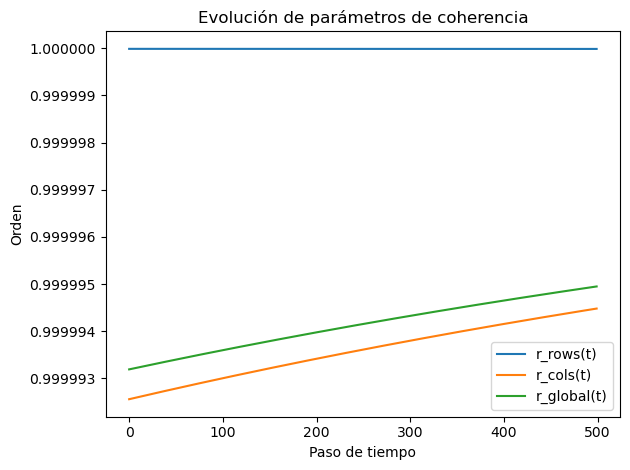

In [11]:
# ==============================
# Bloque 8: Parámetros de coherencia (sin notación científica/offset en el eje Y)
# ==============================
def order_parameter(phases):
    Z = np.exp(1j * phases)        # T x K
    r_t = np.abs(np.mean(Z, axis=1))
    return r_t

r_rows = order_parameter(traj_phi)
r_cols = order_parameter(traj_psi)
phases_global = np.concatenate([traj_phi, traj_psi], axis=1)  # T x (N+M)
r_global = order_parameter(phases_global)

summary = {
    "r_rows_mean": float(np.mean(r_rows)),
    "r_rows_final": float(r_rows[-1]),
    "r_cols_mean": float(np.mean(r_cols)),
    "r_cols_final": float(r_cols[-1]),
    "r_global_mean": float(np.mean(r_global)),
    "r_global_final": float(r_global[-1]),
    "N": int(traj_phi.shape[1]),
    "M": int(traj_psi.shape[1]),
    "K": float(K),
    "dt": float(dt),
    "T_total": float(T_total)
}
summary_df = pd.DataFrame([summary])
display(summary_df)

if SAVE_CSV:
    summary_df.to_csv(f"{SAVE_PREFIX}_coherence_summary.csv", index=False)
    print("Guardado:", f"{SAVE_PREFIX}_coherence_summary.csv")

# Gráfico
fig, ax = plt.subplots()
ax.plot(r_rows, label="r_rows(t)")
ax.plot(r_cols, label="r_cols(t)")
ax.plot(r_global, label="r_global(t)")
ax.set_xlabel("Paso de tiempo")
ax.set_ylabel("Orden")
ax.set_title("Evolución de parámetros de coherencia")
ax.legend()

# --- Desactivar offset y notación científica en Y ---
ax.ticklabel_format(axis='y', style='plain', useOffset=False)

# (Opcional recomendado) Limitar Y para que se vea el detalle sin offset:
ymin = float(min(r_rows.min(), r_cols.min(), r_global.min()))
ymax = float(max(r_rows.max(), r_cols.max(), r_global.max()))
pad = 0.05 * (ymax - ymin + 1e-12)
ax.set_ylim(ymin - pad, ymax + pad)

plt.tight_layout()
if SAVE_PNG:
    plt.savefig(f"{SAVE_PREFIX}_coherence.png", dpi=160)
plt.show()


In [ ]:
# ==============================
# Bloque 9:Selección automática de K_EMBED y N_ELEM_CLUSTERS por rejilla ===
# ==============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def standardized_features_from_UV_A(U_k, V_k, A):
    N, k1 = U_k.shape
    M, k2 = V_k.shape
    assert k1 == k2
    kk = k1
    feats = np.empty((N*M, 2*kk + 1), dtype=float)
    idx = 0
    for i in range(N):
        for j in range(M):
            feats[idx, :kk]      = U_k[i]
            feats[idx, kk:2*kk]  = V_k[j]
            feats[idx, -1]       = A[i, j]
            idx += 1
    mu = feats.mean(axis=0, keepdims=True)
    sigma = feats.std(axis=0, keepdims=True) + 1e-12
    return (feats - mu) / sigma

def kmeans_repeat(X, n_clusters, n_init=5, max_iter=60, random_state=0):
    rng = np.random.default_rng(random_state)
    best_labels = None
    best_centroids = None
    best_inertia = np.inf
    n_samples = X.shape[0]
    for _ in range(n_init):
        C = min(n_clusters, n_samples)
        centroids = X[rng.choice(n_samples, size=C, replace=False)]
        labels = np.zeros(n_samples, dtype=int)
        for _it in range(max_iter):
            d2 = ((X[:, None, :] - centroids[None, :, :])**2).sum(axis=2)
            new_labels = d2.argmin(axis=1)
            if np.array_equal(new_labels, labels):
                break
            labels = new_labels
            new_centroids = np.vstack([X[labels==c].mean(axis=0) if np.any(labels==c) else centroids[c]
                                       for c in range(C)])
            if np.allclose(new_centroids, centroids, atol=1e-6):
                centroids = new_centroids
                break
            centroids = new_centroids
        inertia = 0.0
        for c in range(n_clusters):
            m = (labels == c)
            if not np.any(m): 
                continue
            dif = X[m] - centroids[c]
            inertia += float((dif*dif).sum())
        if inertia < best_inertia:
            best_inertia  = inertia
            best_labels   = labels.copy()
            best_centroids= centroids.copy()
    return best_labels, best_centroids, best_inertia

def davies_bouldin_index(X, labels, centroids):
    C = centroids.shape[0]
    if C <= 1:
        return np.inf
    # dispersión intra
    S = np.zeros(C, dtype=float)
    for i in range(C):
        m = (labels == i)
        if not np.any(m):
            S[i] = 0.0
        else:
            dif = X[m] - centroids[i]
            S[i] = np.mean(np.sqrt((dif*dif).sum(axis=1)))
    # distancias entre centros
    M = np.sqrt(((centroids[:, None, :] - centroids[None, :, :])**2).sum(axis=2)) + 1e-12
    R = np.zeros((C, C), dtype=float)
    for i in range(C):
        for j in range(C):
            if i == j: 
                R[i, j] = -np.inf
            else:
                R[i, j] = (S[i] + S[j]) / M[i, j]
    return float(np.mean(R.max(axis=1)))

# --- SVD de la A_cross normalizada bipartita (recomendada para co-embeddings) ---
A = A_cross.astype(float)
N, M = A.shape
d_r = A.sum(axis=1); d_r[d_r==0] = 1e-12
d_c = A.sum(axis=0); d_c[d_c==0] = 1e-12
Dr_inv_sqrt = np.diag(1.0/np.sqrt(d_r))
Dc_inv_sqrt = np.diag(1.0/np.sqrt(d_c))
A_tilde = Dr_inv_sqrt @ A @ Dc_inv_sqrt

U, S, VT = np.linalg.svd(A_tilde, full_matrices=False)
sv2 = S**2
sv2_total = float(sv2.sum()) + 1e-12
cum_energy = np.cumsum(sv2) / sv2_total

# --- Rejilla ---
Kmax = min(min(N, M), 10)          # k hasta 10 o hasta rank
K_list = list(range(1, Kmax+1))
Cmax  = min(max(2, int(np.ceil(np.sqrt(N*M)))), 20)  # clusters de elementos hasta 20
C_list = list(range(2, Cmax+1))

# Para evitar costos altos, muestrear si hay demasiados elementos (pares i,j)
sample_cap = None
rng = np.random.default_rng(0)

results = []
best = None

def is_pref(r):  # preferimos K con energía SVD suficiente
    return r["sv_energy"] >= 0.85

for k in K_list:
    U_k = U[:, :k]
    V_k = VT[:k, :].T
    Xf = standardized_features_from_UV_A(U_k, V_k, A)

    # --- muestreo opcional ---
    if (sample_cap is not None) and (Xf.shape[0] > sample_cap):
        idx = rng.choice(Xf.shape[0], size=sample_cap, replace=False)
        X_eval = Xf[idx]
    else:
        X_eval = Xf

    for C in C_list:
        labels, centroids, inertia = kmeans_repeat(
            X_eval, n_clusters=C, n_init=5, max_iter=60, random_state=42
        )
        db = davies_bouldin_index(X_eval, labels, centroids)
        rec = {
            "K_embed": k,
            "C_elem": C,
            "db_index": db,
            "inertia": inertia,
            "sv_energy": float(cum_energy[k-1])
        }
        results.append(rec)

        if best is None:
            best = rec
        else:
            a, b = best, rec
            if is_pref(a) and not is_pref(b):
                pass
            elif not is_pref(a) and is_pref(b):
                best = b
            else:
                if b["db_index"] < a["db_index"] - 1e-9:
                    best = b
                elif abs(b["db_index"] - a["db_index"]) <= 1e-9 and b["inertia"] < a["inertia"] - 1e-9:
                    best = b

scores_df = pd.DataFrame(results)
display(scores_df.head())
scores_df.to_csv(f"{SAVE_PREFIX}_grid_scores.csv", index=False)
print("Guardado:", f"{SAVE_PREFIX}_grid_scores.csv")
print("Sugerencia óptima -> K_EMBED =", best["K_embed"], 
      ", N_ELEM_CLUSTERS =", best["C_elem"],
      ", DB =", round(best["db_index"],4), 
      ", energía SVD =", round(best["sv_energy"],3))

# Heatmap DB-index (K vs C)
pivot = scores_df.pivot(index="K_embed", columns="C_elem", values="db_index")
plt.figure()
im = plt.imshow(pivot.values, aspect="auto", origin="lower")
plt.xticks(range(pivot.shape[1]), pivot.columns)
plt.yticks(range(pivot.shape[0]), pivot.index)
plt.colorbar(im, label="Davies–Bouldin (menor es mejor)")
plt.xlabel("N_ELEM_CLUSTERS (C)")
plt.ylabel("K_EMBED (K)")
plt.title("Grid DB-index (K vs C)")
# marca el mejor
try:
    bi = K_list.index(best["K_embed"])
    bj = C_list.index(best["C_elem"])
    plt.scatter([bj], [bi], marker="x")
except Exception:
    pass
plt.tight_layout()
plt.savefig(f"{SAVE_PREFIX}_grid_dbindex.png", dpi=160)
plt.show()
print("Figura guardada:", f"{SAVE_PREFIX}_grid_dbindex.png")


In [18]:
# ============================================================
# Bloque 10: REPLICABILIDAD del selector del Bloque 9
#   - Test A: misma semilla => resultado idéntico (bit a bit)
#   - Test B: semillas distintas => sensibilidad al muestreo (sample_cap)
#
# Requiere en memoria (idéntico a Bloque 9):
#   - A_cross
#   - standardized_features_from_UV_A, kmeans_repeat, davies_bouldin_index
# ============================================================

import numpy as np
import pandas as pd

def grid_best_block9(A_cross, sample_cap=8000, rng_seed=0,
                     Kmax_cap=10, Cmax_cap=20, kmeans_state=42):
    # --- (1) A y normalización bipartita: IGUAL al Bloque 9 ---
    A = A_cross.astype(float)
    N, M = A.shape
    d_r = A.sum(axis=1); d_r[d_r == 0] = 1e-12
    d_c = A.sum(axis=0); d_c[d_c == 0] = 1e-12
    Dr_inv_sqrt = np.diag(1.0/np.sqrt(d_r))
    Dc_inv_sqrt = np.diag(1.0/np.sqrt(d_c))
    A_tilde = Dr_inv_sqrt @ A @ Dc_inv_sqrt

    # --- (2) SVD: IGUAL ---
    U, S, VT = np.linalg.svd(A_tilde, full_matrices=False)
    sv2 = S**2
    sv2_total = float(sv2.sum()) + 1e-12
    cum_energy = np.cumsum(sv2) / sv2_total

    # --- (3) Rejilla: IGUAL ---
    Kmax = min(min(N, M), Kmax_cap)
    K_list = list(range(1, Kmax+1))
    Cmax = min(max(2, int(np.ceil(np.sqrt(N*M)))), Cmax_cap)
    C_list = list(range(2, Cmax+1))

    rng = np.random.default_rng(rng_seed)

    def is_pref(rec):
        return rec["sv_energy"] >= 0.85

    results = []
    best = None

    # --- (4) Loop idéntico al Bloque 9 ---
    for k in K_list:
        U_k = U[:, :k]
        V_k = VT[:k, :].T

        # standardized_features_from_UV_A: IGUAL (incluye estandarización global)
        Xf = standardized_features_from_UV_A(U_k, V_k, A)

        # muestreo opcional: IGUAL (ojo con sample_cap None)
        if (sample_cap is not None) and (Xf.shape[0] > sample_cap):
            idx = rng.choice(Xf.shape[0], size=sample_cap, replace=False)
            X_eval = Xf[idx]
        else:
            X_eval = Xf

        for C in C_list:
            labels, centroids, inertia = kmeans_repeat(
                X_eval, n_clusters=C, n_init=5, max_iter=60, random_state=kmeans_state
            )
            db = davies_bouldin_index(X_eval, labels, centroids)

            rec = {
                "K_embed": int(k),
                "C_elem": int(C),
                "db_index": float(db),
                "inertia": float(inertia),
                "sv_energy": float(cum_energy[k-1]),
            }
            results.append(rec)

            if best is None:
                best = rec
            else:
                a, b = best, rec
                if is_pref(a) and not is_pref(b):
                    pass
                elif not is_pref(a) and is_pref(b):
                    best = b
                else:
                    if b["db_index"] < a["db_index"] - 1e-9:
                        best = b
                    elif abs(b["db_index"] - a["db_index"]) <= 1e-9 and b["inertia"] < a["inertia"] - 1e-9:
                        best = b

    scores_df = pd.DataFrame(results)
    return best, scores_df


# ----------------------------
# CONFIG
# ----------------------------
N_REPEATS_SAMESEED = 5
N_REPEATS_DIFFSEED = 10
SAMPLE_CAP = None
FIXED_SEED = 0
KMEANS_STATE = 42

# ----------------------------
# Test A: misma semilla => debe ser idéntico
# ----------------------------
best0, df0 = grid_best_block9(A_cross, sample_cap=SAMPLE_CAP, rng_seed=FIXED_SEED, kmeans_state=KMEANS_STATE)
df0s = df0.sort_values(["K_embed","C_elem"]).reset_index(drop=True)
h0 = pd.util.hash_pandas_object(df0s[["K_embed","C_elem","db_index","inertia","sv_energy"]], index=False).sum()

bests_A = []
hashes_A = []

for r in range(N_REPEATS_SAMESEED):
    bestA, dfA = grid_best_block9(A_cross, sample_cap=SAMPLE_CAP, rng_seed=FIXED_SEED, kmeans_state=KMEANS_STATE)
    dfAs = dfA.sort_values(["K_embed","C_elem"]).reset_index(drop=True)
    hA = pd.util.hash_pandas_object(dfAs[["K_embed","C_elem","db_index","inertia","sv_energy"]], index=False).sum()

    bests_A.append((bestA["K_embed"], bestA["C_elem"], bestA["db_index"], bestA["inertia"]))
    hashes_A.append(int(hA))

print("TEST A (misma semilla):")
print(" - baseline best:", (best0["K_embed"], best0["C_elem"], best0["db_index"], best0["inertia"]))
print(" - bests:", bests_A)
print(" - hashes:", hashes_A)
print(" - ¿idéntico a baseline? ->", (all(h == int(h0) for h in hashes_A) and all(b == bests_A[0] for b in bests_A)))

# ----------------------------
# Test B: semillas distintas => sensibilidad al muestreo
# ----------------------------
records_B = []
for s in range(N_REPEATS_DIFFSEED):
    seed = FIXED_SEED + 1000 + s
    bestB, _ = grid_best_block9(A_cross, sample_cap=SAMPLE_CAP, rng_seed=seed, kmeans_state=KMEANS_STATE)
    records_B.append({
        "rng_seed": int(seed),
        "K_best": int(bestB["K_embed"]),
        "C_best": int(bestB["C_elem"]),
        "DB_best": float(bestB["db_index"]),
        "inertia_best": float(bestB["inertia"]),
        "sv_energy_best": float(bestB["sv_energy"]),
    })

resB = pd.DataFrame(records_B)
print("\nTEST B (semillas distintas): frecuencia de (K*,C*):")
display(resB.groupby(["K_best","C_best"]).size().reset_index(name="count").sort_values("count", ascending=False))
display(resB)


TEST A (misma semilla):
 - baseline best: (5, 2, 0.11444390661380616, 85626.17492128747)
 - bests: [(5, 2, 0.11444390661380616, 85626.17492128747), (5, 2, 0.11444390661380616, 85626.17492128747), (5, 2, 0.11444390661380616, 85626.17492128747), (5, 2, 0.11444390661380616, 85626.17492128747), (5, 2, 0.11444390661380616, 85626.17492128747)]
 - hashes: [8668305388662194067, 8668305388662194067, 8668305388662194067, 8668305388662194067, 8668305388662194067]
 - ¿idéntico a baseline? -> True

TEST B (semillas distintas): frecuencia de (K*,C*):


,K_best,C_best,count
0,1,3,7
2,2,3,2
1,1,15,1


,rng_seed,K_best,C_best,DB_best,inertia_best,sv_energy_best
0,1000,1,3,0.333668,1690.900287,1.0
1,1001,1,3,0.347946,1759.277673,1.0
2,1002,1,3,0.315958,1509.831102,1.0
3,1003,1,3,0.316016,1565.429258,1.0
4,1004,2,3,0.354634,6499.975294,1.0
5,1005,1,3,0.351907,1721.776340,1.0
6,1006,1,3,0.331308,1564.985927,1.0
7,1007,1,3,0.352227,1796.891570,1.0
8,1008,1,15,0.437212,105.210004,1.0
9,1009,2,3,0.352208,5462.939452,1.0



## Bloque extra: **Clustering de ELEMENTOS** de `A_cross`

Agrupa cada **par (i,j)** (elemento de la matriz cruzada) usando un embedding bipartito (SVD de la afinidad normalizada) y **k-means** sobre el vector concatenado \([U_k(i,:), V_k(j,:), A_{ij}]\).
Genera:
- Gráfico de tamaños de grupos
- CSV `kuramoto_bipartito_element_clusters.csv` con columnas: `row_i, col_j, cluster, X_value, A_cross_value`
- Impresión de listas por cluster: `(i,j) -> X[i,j], A_cross[i,j]`


Usando selección óptima -> K_EMBED = 1 , N_ELEM_CLUSTERS = 3


,row_i,col_j,cluster,X_value,A_cross_value
0,0,0,2,354.0,1.000000
1,0,1,1,817.0,0.999866
2,0,2,2,50.0,0.999997
3,0,3,1,31.0,0.999848
4,0,4,2,448.0,1.000000


Guardado: kuramoto_bipartito_element_clusters.csv
Tamaños por cluster:
cluster
0      23675
1     143545
2    1922238
Name: count, dtype: int64


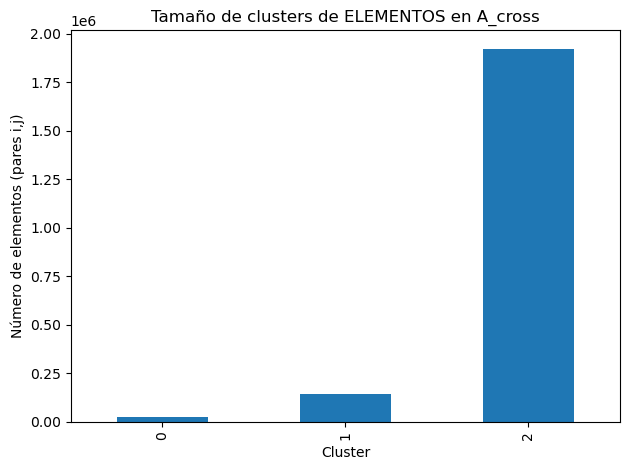

\nCluster 0 (n=23675):
 (i=249.0, j=0.0) -> X=2732, A_cross=1.0000
 (i=249.0, j=1.0) -> X=4.186e+04, A_cross=0.9999
 (i=249.0, j=2.0) -> X=1384, A_cross=1.0000
 (i=249.0, j=4.0) -> X=92, A_cross=1.0000
 (i=249.0, j=6.0) -> X=89, A_cross=1.0000
 (i=249.0, j=7.0) -> X=17, A_cross=1.0000
 (i=249.0, j=8.0) -> X=1.634e+04, A_cross=1.0000
 (i=249.0, j=9.0) -> X=1, A_cross=1.0000
 (i=249.0, j=10.0) -> X=0, A_cross=1.0000
 (i=249.0, j=11.0) -> X=2, A_cross=1.0000
 (i=249.0, j=12.0) -> X=0, A_cross=1.0000
 (i=249.0, j=13.0) -> X=9, A_cross=1.0000
 (i=249.0, j=14.0) -> X=1, A_cross=1.0000
 (i=249.0, j=15.0) -> X=47, A_cross=1.0000
 (i=249.0, j=16.0) -> X=280, A_cross=1.0000
 (i=249.0, j=17.0) -> X=47, A_cross=1.0000
 (i=249.0, j=18.0) -> X=260, A_cross=1.0000
 (i=249.0, j=19.0) -> X=10, A_cross=1.0000
 (i=249.0, j=20.0) -> X=17, A_cross=1.0000
 (i=249.0, j=21.0) -> X=39, A_cross=1.0000
 (i=249.0, j=22.0) -> X=2, A_cross=1.0000
 (i=249.0, j=23.0) -> X=229, A_cross=1.0000
 (i=249.0, j=24.0) -> X=4

In [14]:

# ==============================
# Clustering de ELEMENTOS (i,j) de A_cross
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def element_pair_clustering(A_nm, X_original, n_elem_clusters=6, k_embed=6, random_state=0, max_iter=60):
    A = np.asarray(A_nm, dtype=float)
    N, M = A.shape

    # --- Normalización bipartita D_r^{-1/2} A D_c^{-1/2}
    d_r = A.sum(axis=1); d_r[d_r==0] = 1e-12
    d_c = A.sum(axis=0); d_c[d_c==0] = 1e-12
    Dr_inv_sqrt = np.diag(1.0/np.sqrt(d_r))
    Dc_inv_sqrt = np.diag(1.0/np.sqrt(d_c))
    A_tilde = Dr_inv_sqrt @ A @ Dc_inv_sqrt

    # --- SVD truncada
    U, S, VT = np.linalg.svd(A_tilde, full_matrices=False)
    kk = int(min(k_embed, U.shape[1], VT.shape[0]))
    if kk < 1:
        kk = 1
    U_k = U[:, :kk]      # N x kk
    V_k = VT[:kk, :].T   # M x kk

    # --- Construir features por elemento (i,j): [U_k(i,:), V_k(j,:), A_ij]
    feats = np.empty((N*M, 2*kk + 1), dtype=float)
    coords = np.empty((N*M, 2), dtype=int)
    idx = 0
    for i in range(N):
        for j in range(M):
            feats[idx, :kk] = U_k[i, :]
            feats[idx, kk:2*kk] = V_k[j, :]
            feats[idx, -1] = A[i, j]  # valor de afinidad
            coords[idx, 0] = i
            coords[idx, 1] = j
            idx += 1

    # --- Estandarizar features
    mu = feats.mean(axis=0, keepdims=True)
    sigma = feats.std(axis=0, keepdims=True) + 1e-12
    Xf = (feats - mu) / sigma

    # --- k-means minimalista
    rng = np.random.default_rng(random_state)
    C = min(n_elem_clusters, Xf.shape[0])
    centroids = Xf[rng.choice(Xf.shape[0], size=C, replace=False)]
    labels = np.zeros(Xf.shape[0], dtype=int)

    for _ in range(max_iter):
        d2 = ((Xf[:, None, :] - centroids[None, :, :])**2).sum(axis=2)  # (NM) x C
        new_labels = d2.argmin(axis=1)
        if np.array_equal(new_labels, labels):
            break
        labels = new_labels
        new_centroids = np.vstack([Xf[labels==c].mean(axis=0) if np.any(labels==c) else centroids[c]
                                   for c in range(C)])
        if np.allclose(new_centroids, centroids, atol=1e-6):
            centroids = new_centroids
            break
        centroids = new_centroids

    # --- Construir DataFrame de salida
    out = []
    for idx, (i, j) in enumerate(coords):
        out.append({
            "row_i": int(i),
            "col_j": int(j),
            "cluster": int(labels[idx]),
            "X_value": float(X_original[i, j]) if (i < X_original.shape[0] and j < X_original.shape[1]) else np.nan,
            "A_cross_value": float(A[i, j]),
        })
    df = pd.DataFrame(out)
    return df

# Parámetros del usuario (ajustables)
N_ELEM_CLUSTERS = int(best["C_elem"])
K_EMBED         = int(best["K_embed"])
RANDOM_STATE    = 0
print("Usando selección óptima ->",
      "K_EMBED =", K_EMBED, ", N_ELEM_CLUSTERS =", N_ELEM_CLUSTERS)


# Ejecutar clustering de elementos sobre A_cross
df_elems = element_pair_clustering(A_cross, X, n_elem_clusters=N_ELEM_CLUSTERS, k_embed=K_EMBED, random_state=RANDOM_STATE)
display(df_elems.head())

# Guardar CSV
csv_path = f"Resultados_Bipartito/{SAVE_PREFIX}_element_clusters.csv"
df_elems.to_csv(csv_path, index=False)
print("Guardado:", csv_path)

# Resumen de tamaños por cluster
sizes = df_elems["cluster"].value_counts().sort_index()
print("Tamaños por cluster:")
print(sizes)

# Gráfico: barras de tamaños
plt.figure()
sizes.sort_index().plot(kind="bar")
plt.xlabel("Cluster")
plt.ylabel("Número de elementos (pares i,j)")
plt.title("Tamaño de clusters de ELEMENTOS en A_cross")
plt.tight_layout()
if SAVE_PNG:
    plt.savefig(f"{SAVE_PREFIX}_element_cluster_sizes.png", dpi=160)
plt.show()

# Listado por cluster (coordenadas y valores)
max_per_cluster_to_print = 50  # por si NM es grande
for c in sorted(df_elems["cluster"].unique()):
    sub = df_elems[df_elems["cluster"]==c]
    print(f"\\nCluster {c} (n={len(sub)}):")
    for _, r in sub.head(max_per_cluster_to_print).iterrows():
        print(f" (i={r['row_i']}, j={r['col_j']}) -> X={r['X_value']:.4g}, A_cross={r['A_cross_value']:.4f}")
    if len(sub) > max_per_cluster_to_print:
        print(f" ... (+{len(sub)-max_per_cluster_to_print} más)")
